In [1]:
import torch
from riemannian_geometry import PullbackRiemannianManifold
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [2]:
torch.set_default_dtype(torch.float64)

In [3]:
@dataclass
class Sphere(PullbackRiemannianManifold):
    r: float

    def coordinate_map(self, coords: torch.Tensor) -> torch.Tensor:
        theta, phi = coords[..., 0], coords[..., 1]
        return torch.stack((
            self.r * torch.sin(theta) * torch.cos(phi),
            self.r * torch.sin(theta) * torch.sin(phi),
            self.r * torch.cos(theta),
        ), dim=-1)


In [4]:
sphere = Sphere(r=1.0)

In [5]:
base_s = torch.tensor([1.1, 0.3])
tangent_s_exp = torch.tensor([0.3, -0.25])

In [6]:
sphere.Hamiltonian(base_s, tangent_s_exp)

tensor(0.0843, grad_fn=<MulBackward0>)

In [7]:
sphere.g(base_s)

tensor([[1.0000, 0.0000],
        [0.0000, 0.7943]], grad_fn=<ViewBackward0>)

In [5]:
sphere.g(torch.tensor((0., 0.)))

tensor([[1., 0.],
        [0., 1.]], grad_fn=<ViewBackward0>)

In [7]:
sphere.ric(torch.tensor(((0.7, -0.4), (-0.2, 0.8), (0.1, 0.1))))

tensor([2.0000, 2.0000, 2.0000], grad_fn=<ViewBackward0>)

In [7]:
geodesic = sphere.exponential_map(
    source=base_s,
    direction=20*tangent_s_exp,
    factor=1,
    resolution=64
)

Computing exponential map: 100%|██████████| 64/64 [00:01<00:00, 44.46it/s]


In [9]:
geodesic_ambient = sphere.coordinate_map(geodesic.detach())

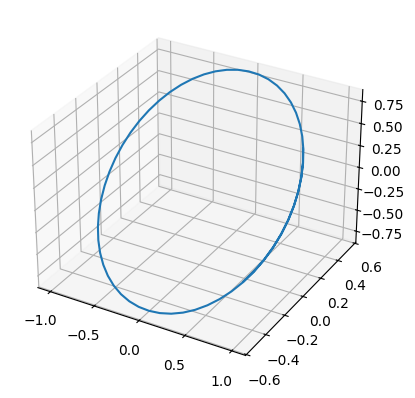

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(*geodesic_ambient.T)
plt.show()